#Loading our data for preprocessing

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Employee.csv')
df

Saving Employee.csv to Employee.csv


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


#1. Data Exploration:
● Explore the data, list down the unique values in each feature and find its length.

● Perform the statistical analysis and renaming of the columns

In [3]:
import pandas as pd

df = pd.read_csv("Employee.csv")


for col in df.columns:
    print(col, ":", df[col].unique())
    print("Length:", df[col].nunique(), "\n")

print(df.describe())


df.columns = ["company", "age", "salary", "place", "country", "gender"]
print(df.columns)

Company : ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 6 

Age : [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29 

Salary : [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 40 

Place : ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 11 

Country : ['India']
Length: 1 

Gender : [0 1]
Length: 2 

              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.0

#2. Data Cleaning:
● Find the missing and inappropriate values, treat them appropriately.

● Remove all duplicate rows.

● Find the outliers.

● Replace the value 0 in age as NaN Treat the null
values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


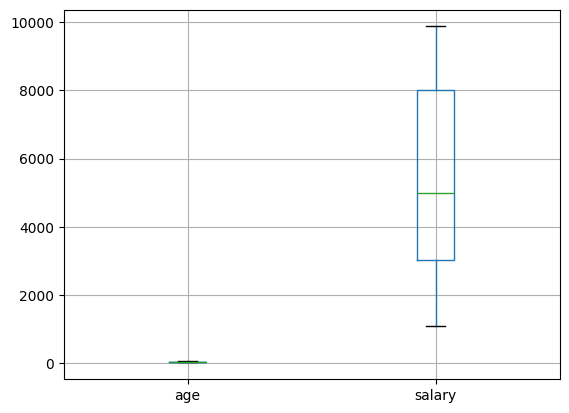

In [17]:
import pandas as pd

df = pd.read_csv("Employee.csv")
df.columns = ["company", "age", "salary", "place", "country", "gender"]

df["company"] = df["company"].replace({
    "Tata Consultancy Services": "TCS",
    "Infosys Pvt Lmt": "Infosys",
    "Congnizant": "CTS"
})


df["age"] = df["age"].replace(0, float("nan"))

df = df.drop_duplicates()


df.boxplot(column=["age", "salary"])


df.fillna({
    "age": df["age"].median(),
    "salary": df["salary"].mean(),
    "company": df["company"].mode()[0],
    "place": df["place"].mode()[0]
}, inplace=True)

print(df.isnull().sum())

#3.Data Analysis:
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


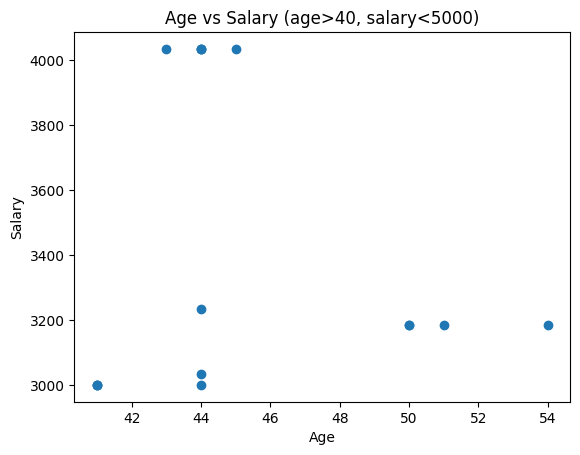

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


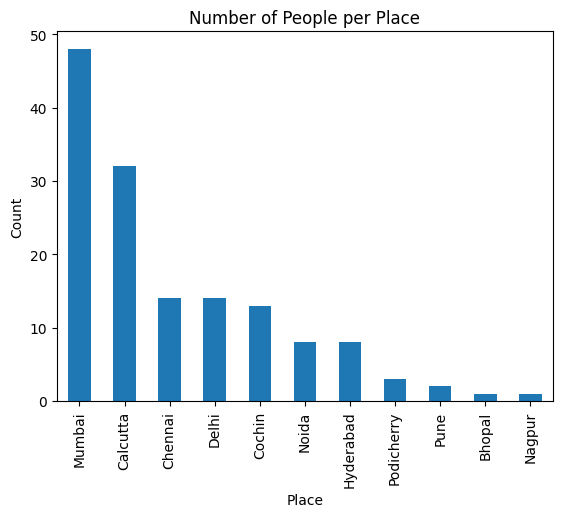

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


filtered = df[(df["age"] > 40) & (df["salary"] < 5000)]
print(filtered)


plt.scatter(filtered["age"], filtered["salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary (age>40, salary<5000)")
plt.show()


print(place_counts)

place_counts.plot(kind="bar")
plt.xlabel("Place")
plt.ylabel("Count")
plt.title("Number of People per Place")
plt.show()

#4.Data Encoding:
● Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["company"] = le.fit_transform(df["company"])

df = pd.get_dummies(df, columns=["place"])

print(df.head())

   company   age       salary country  gender  place_Bhopal  place_Calcutta  \
0        2  20.0  5283.471074   India       0         False           False   
1        1  30.0  5283.471074   India       0         False           False   
2        2  35.0  2300.000000   India       0         False            True   
3        1  40.0  3000.000000   India       0         False           False   
4        2  23.0  4000.000000   India       0         False           False   

   place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  place_Mumbai  \
0           True         False        False            False         False   
1          False         False        False            False          True   
2          False         False        False            False         False   
3          False         False         True            False         False   
4          False         False        False            False          True   

   place_Nagpur  place_Noida  place_Podicherry  place_Pu

#5.Feature Scaling:
 ● After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_num = df.drop(columns=["country"])

scaler = StandardScaler()
df_standard = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)

minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df_num), columns=df_num.columns)

print(df_standard.head())
print(df_minmax.head())

    company       age    salary    gender  place_Bhopal  place_Calcutta  \
0  1.019256 -1.484676  0.000000 -0.534522     -0.083624       -0.534522   
1 -0.214129 -0.267174  0.000000 -0.534522     -0.083624       -0.534522   
2  1.019256  0.341577 -1.264122 -0.534522     -0.083624        1.870829   
3 -0.214129  0.950328 -0.967526 -0.534522     -0.083624       -0.534522   
4  1.019256 -1.119426 -0.543818 -0.534522     -0.083624       -0.534522   

   place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  place_Mumbai  \
0       3.047247     -0.315018    -0.328165        -0.242536     -0.707107   
1      -0.328165     -0.315018    -0.328165        -0.242536      1.414214   
2      -0.328165     -0.315018    -0.328165        -0.242536     -0.707107   
3      -0.328165     -0.315018     3.047247        -0.242536     -0.707107   
4      -0.328165     -0.315018    -0.328165        -0.242536      1.414214   

   place_Nagpur  place_Noida  place_Podicherry  place_Pune  
0     -0.083624    